# Spam Detection Using Machine Learning
## COM7018 – Machine Learning and Intelligent Agents
### Research Question
Can machine learning accurately classify SMS messages as spam or ham (legitimate messages)?
#### Student ID 
22435086
#### Name
Pallavi kainth
#### Academic Year
2025–2026


# 1. Introduction

Spam is any unsolicited communication, including ads, fraud notices, phishing and malicious material. With the continued and ever-expanding growth of mobile communication, spam filtering has become an essential cybersecurity and data science application. Among the strategies that have been used to construct an automated spam detector, machine learning algorithms seem to have been the most popular ones due to their capacity to learn over previously labelled classified messages and to classify new ones efficiently (Almeida, Gómez Hidalgo and Yamakami, 2011).

One of the most prevalent uses of machine learning is the classification of text. Supervised learning algorithms are able to learn relationships between the input features and known labels and work well in classification problems like spam detection, as per Géron (2022). Moreover, there are useful libraries of machine learning algorithms (e.g. Scikit-learn) available that offer efficient implementations of classification algorithms and evaluation tools for this to enable comprehensive machine learning development practice (Pedregosa et al., 2011).

This project aims to see that if machine learning algorithms are able to correctly classify SMS messages based on the condition whether they are Spam and Ham (legitimate message). An end-to-end machine learning workflow for data exploration, preprocessing, model training, hyperparameter tuning and evaluation was used to develop and evaluate multiple classification models on the SMS Spam Collection dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 2. Data Collection and Exploratory Data Analysis

The Spam Collection dataset from SMS was chosen for this study. The dataset comprises 5,572 spam and 10,000 ham (legitimate) SMS messages and is a previously existing dataset created for research SMS spam filter systems (Almeida, Gómez Hidalgo and Yamakami, 2011).

After the initial inspection, there were no missing values identified, meaning that there was no need for extensive data cleaning before using the data for machine learning analysis. The data set comprised 4,825 legitimate (ham) messages and 747 spam (spam) messages(Ahmadi et al., 2025).Addressing the potential class imbalance problem, the dataset is balanced by using random under-sampling to obtain the same number of ham and spam messages. A balanced dataset was then subjected to some further exploratory analysis. 

Further, common spam-related words were determined using word frequency analysis. The results in this work clearly reveal linguistic and structural distinction between spam and ham messages and tend to prove the feasibility of employing machine learning methods in the automated identification of spam messages.

In [2]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [6]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
X_original = df['message']

y_original = df['label']

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_original = TfidfVectorizer(
    stop_words='english'
)

X_original = vectorizer_original.fit_transform(
    X_original
)

In [9]:
from sklearn.model_selection import train_test_split

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_original = MultinomialNB()

nb_original.fit(
    X_train_o,
    y_train_o
)

pred_original = nb_original.predict(
    X_test_o
)

In [11]:
print(y_test_o.unique())

['ham' 'spam']


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(
    "Accuracy:",
    accuracy_score(y_test_o, pred_original)
)

print(
    "Precision:",
    precision_score(
        y_test_o,
        pred_original,
        pos_label='spam'
    )
)

print(
    "Recall:",
    recall_score(
        y_test_o,
        pred_original,
        pos_label='spam'
    )
)

print(
    "F1:",
    f1_score(
        y_test_o,
        pred_original,
        pos_label='spam'
    )
)

Accuracy: 0.968609865470852
Precision: 1.0
Recall: 0.7666666666666667
F1: 0.8679245283018868


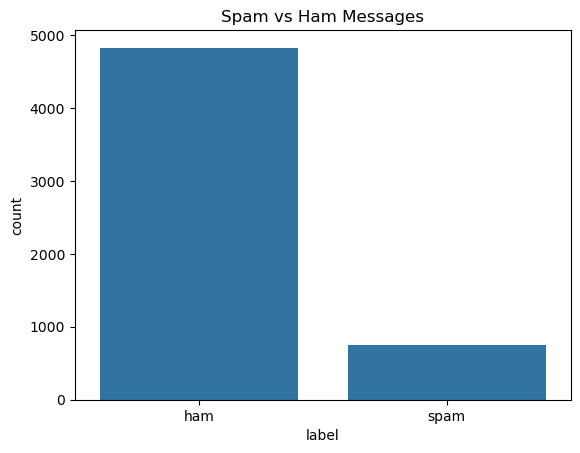

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")

plt.show()

In [14]:
df['length'] = df['message'].apply(len)

df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [15]:
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


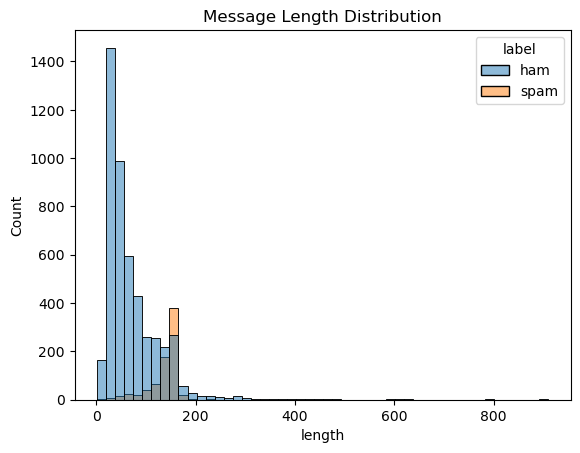

In [16]:
sns.histplot(
    data=df,
    x='length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")

plt.show()

In [17]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

In [18]:
df['label']

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: label, Length: 5572, dtype: int64

In [19]:
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

# Handling Class Imbalance

Originally, there were significantly more ham messages than spam messages. This class imbalance can lead to a predictive model that is more likely to identify the groups it is familiar with, while being less capable of correctly identifying the spam messages.
To overcome this, random under sampling was done. The number of ham messages was also reduced, to form a balanced data set for model training and evaluation in order to make the number of ham messages similar to that of spam messages.

In [20]:


ham = df[df['label'] == 0]

spam = df[df['label'] == 1]



ham_sample = ham.sample(
    n=len(spam),
    random_state=42
)



balanced_df = pd.concat([
    ham_sample,
    spam
])



balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
)

balanced_df['label'].value_counts()

label
1    747
0    747
Name: count, dtype: int64

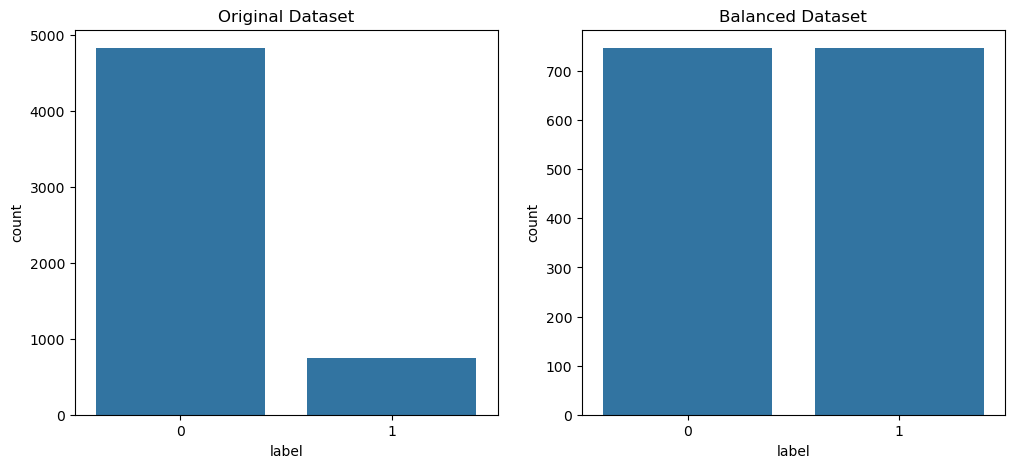

In [21]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(12,5)
)

sns.countplot(
    x='label',
    data=df,
    ax=ax[0]
)

ax[0].set_title(
    "Original Dataset"
)

sns.countplot(
    x='label',
    data=balanced_df,
    ax=ax[1]
)

ax[1].set_title(
    "Balanced Dataset"
)

plt.show()

The balanced dataset produced substantially higher recall and F1-score than the original dataset. Although accuracy decreased slightly, balancing reduced class bias and improved the model's ability to detect spam messages. This demonstrates the importance of addressing class imbalance in classification problems.

In [22]:


balanced_df['length'] = balanced_df['message'].apply(len)

balanced_df.groupby(
    'label'
)['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,747.0,69.117805,54.961157,3.0,33.0,51.0,86.0,588.0
1,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


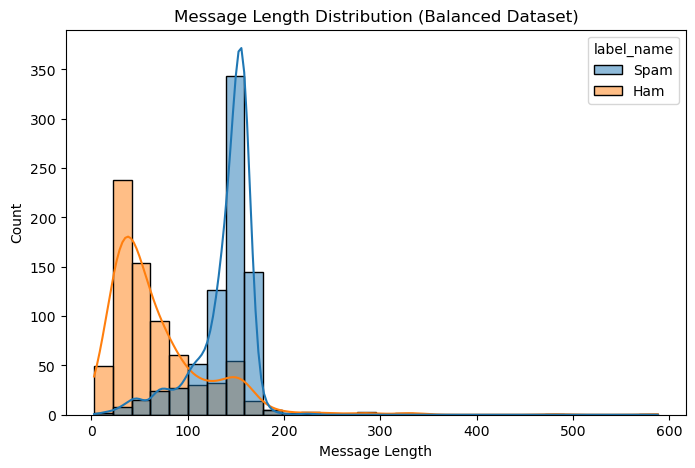

In [23]:
balanced_df['label_name'] = balanced_df['label'].map({
    0: 'Ham',
    1: 'Spam'
})
plt.figure(figsize=(8,5))

sns.histplot(
    data=balanced_df,
    x='length',
    hue='label_name',
    bins=30,
    kde=True
)

plt.title("Message Length Distribution (Balanced Dataset)")
plt.xlabel("Message Length")
plt.ylabel("Count")

plt.show()

In [24]:
balanced_df['word_count'] = (
    balanced_df['message']
    .apply(lambda x: len(x.split()))
)

In [25]:
balanced_df.groupby(
    'label'
)['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,747.0,13.863454,11.102621,1.0,7.0,10.0,18.0,125.0
1,747.0,23.851406,5.811898,2.0,22.0,25.0,28.0,35.0


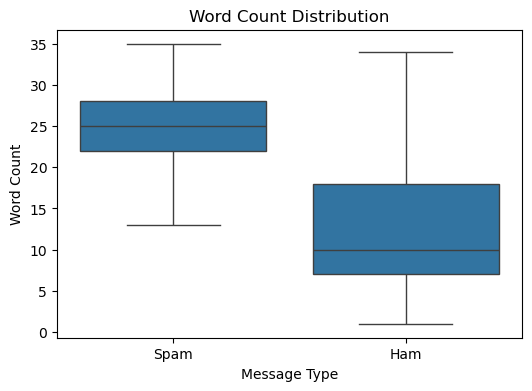

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='label_name',
    y='word_count',
    data=balanced_df,
    showfliers=False
)

plt.title("Word Count Distribution")
plt.xlabel("Message Type")
plt.ylabel("Word Count")

plt.show()

### Word Count Findings

The results of word count analysis showed the clear difference between the detection of ham and spam. The average number of words in spam messages was around 24 words and the average number of words in ham messages was around 14 words.

This indicates that spam emails tend to be longer in nature as they convey some kind of advertisement, prompt or instructions. On the other hand, mail that is legal usually is brief, conversational, and a bit old-fashioned.

In [27]:
balanced_df['digit_count'] = (
    balanced_df['message']
    .str.count(r'\d')
)
balanced_df.groupby(
    'label'
)['digit_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,747.0,0.266399,0.880216,0.0,0.0,0.0,0.0,9.0
1,747.0,15.759036,8.755896,0.0,10.0,16.0,22.0,47.0


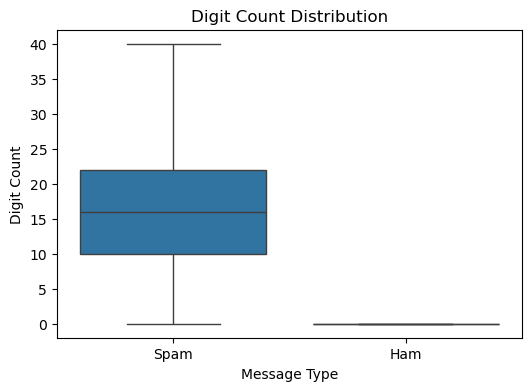

In [28]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='label_name',
    y='digit_count',
    data=balanced_df,
    showfliers=False
)

plt.title("Digit Count Distribution")
plt.xlabel("Message Type")
plt.ylabel("Digit Count")

plt.show()

### Digit Count Findings

The digit count analysis found a significant difference between the number of digits in ham and spam messages. Almost none of the digits in ham messages were numerical, as the median number of digits in a message was about 0.27 digits. Importantly, spam messages had about 15.76 digits on average.

The result indicated that the numerical data is a good indicator of spam. A lot of spams contain telephone numbers, promotional codes, prize amounts, financial offers etc., with consequently much higher “n” factor.

In [29]:
balanced_df['exclamation_count'] = (
    balanced_df['message']
    .str.count('!')
)
balanced_df.groupby(
    'label'
)['exclamation_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,747.0,0.178046,0.633430,0.0,0.0,0.0,0.0,9.0
1,747.0,0.725569,0.939698,0.0,0.0,0.0,1.0,5.0


In [30]:
balanced_df['exclamation_count'] = balanced_df['message'].apply(
    lambda x: x.count('!')
)

In [31]:
balanced_df[['message','exclamation_count']].head()

,message,exclamation_count
1406,"URGENT, IMPORTANT INFORMATION FOR O2 USER. TOD...",1
1006,Panasonic & BluetoothHdset FREE. Nokia FREE. M...,0
4369,Do you want a new Video handset? 750 any time ...,0
1662,Hi if ur lookin 4 saucy daytime fun wiv busty ...,0
1462,09066362231 URGENT! Your mobile No 07xxxxxxxxx...,4


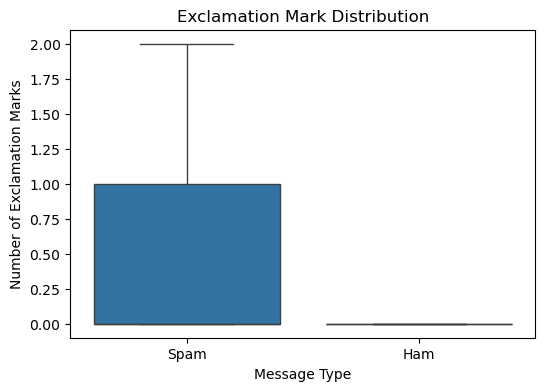

In [32]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='label_name',
    y='exclamation_count',
    data=balanced_df,
    showfliers=False
)

plt.title("Exclamation Mark Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Exclamation Marks")

plt.show()

### Exclamation Mark Findings

The analysis resulted in the discovery that ham messages have less number of exclamation mark than spam messages from the exclamation mark analysis. The average number of exclamation marks in spam messages was about 0.73, whereas the average number of exclamation marks in ham messages was 0.18.

This discovery matches up with the way spam messages are promoting and drawing unwanted attention, since a lot of them rely on the punctuation used the make them attention-grabbing, and suggest quick action.

In [33]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS)

custom_stopwords.update([
    'u',
    'ur',
    'im',
    'dont',
    'just',
    'ok',
    'll',
    'txting'
])

spam_text = " ".join(
    balanced_df[
        balanced_df['label'] == 1
    ]['message']
)

words = [
    word.lower()
    for word in spam_text.split()
    if word.lower() not in custom_stopwords
    and word.isalpha()
]

top_words = Counter(words).most_common(15)

word_df = pd.DataFrame(
    top_words,
    columns=['Word', 'Count']
)

word_df

,Word,Count
0,free,180
1,txt,136
2,text,112
3,mobile,109
4,claim,106
5,reply,101
6,stop,89
7,new,69
8,send,65
9,nokia,64


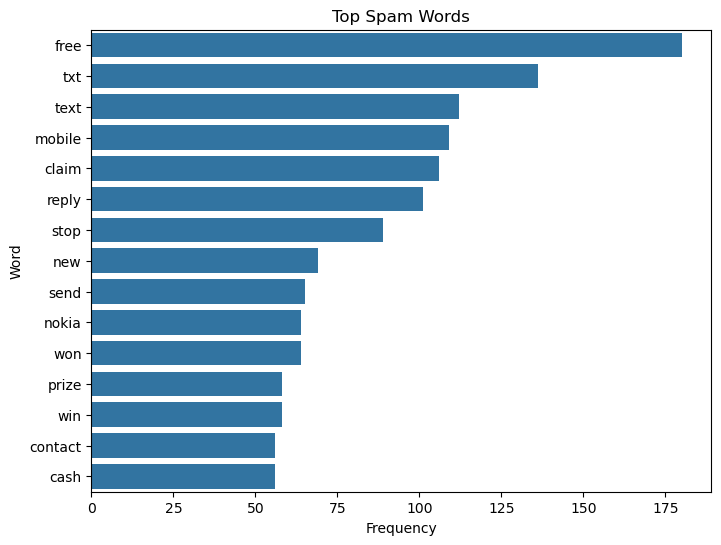

In [34]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='Count',
    y='Word',
    data=word_df
)

plt.title("Top Spam Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

## Spam Word Frequency Findings

Several words were identified through word frequency analysis that are commonly used in spam messages. Promotional terms, like "free" and "call" and “txt” were commonly used in spam communications.
These results are similar to characteristics of spams as they frequently include offers for prizes, promotions or calls for immediate responses.These terms indicate the “weighting” need to use TF-IDF vectorisation so that the machine learning algorithms obtain the significant textual patterns of spam content.

In [35]:
X = balanced_df['message']
y = balanced_df['label']

# 3. Machine Learning Process

Class labels were transformed to numerical prior to model trainings. The ham messages were coded 0 and spam messages were coded 1. This change was important because all machine learning methods need to be fed as data in the form of numbers.

These text messages were then translated with the technique of Term Frequency–Inverse Document Frequency (TF-IDF) to yield numerical feature vectors. TF-IDF is also widely adopted in natural language processing because it helps to highlight the significance of words in a document, thus mitigating the impact of common terms (Géron, 2022).

Vectorisation created 8,404 numerical features, each indicating significance of words in each message. The dataset was then split in 80:20 ratio for training and testing. The model development was based on the training set and the testing set was used to test the model's performance on actual unseen data.

For comparison, two supervised machine learning algorithms were chosen - Multinomial Naive Bayes and Logistic Regression. Logistic Regression (LR) is one of the more famous classification techniques and is often used as a benchmark for binary classification and for use as a comparison for multinomial Naive Bayes (MNB) in text classification, which is another area to which it has been applied extensively (Pedregosa et al., 2011).

In [36]:
X = balanced_df['message']
y = balanced_df['label']
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english'
)

X = vectorizer.fit_transform(X)

In [37]:
X.shape

(1494, 4290)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
X_train.shape

(1195, 4290)

In [40]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(
    X_train,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [41]:
nb_pred = nb.predict(X_test)

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:",
      accuracy_score(y_test, nb_pred))

print("Precision:",
      precision_score(y_test, nb_pred))

print("Recall:",
      recall_score(y_test, nb_pred))

print("F1:",
      f1_score(y_test, nb_pred))

Accuracy: 0.9632107023411371
Precision: 0.9586206896551724
Recall: 0.9652777777777778
F1: 0.9619377162629758


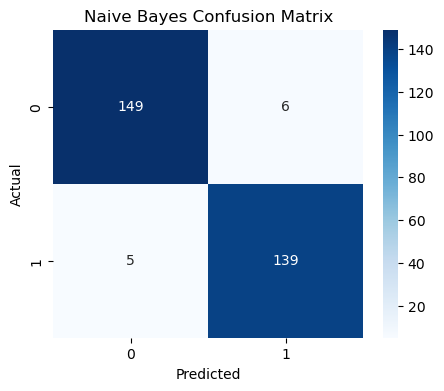

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [45]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",
      f1_score(y_test, lr_pred))

Accuracy: 0.9531772575250836
Precision: 0.9850746268656716
Recall: 0.9166666666666666
F1: 0.9496402877697842


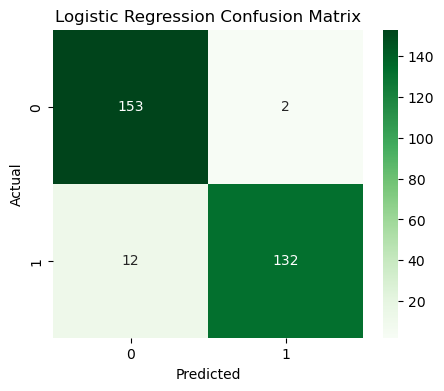

In [46]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    random_state=42
)

svm.fit(
    X_train,
    y_train
)

svm_pred = svm.predict(X_test)

In [48]:
print("Accuracy:",
      accuracy_score(y_test, svm_pred))

print("Precision:",
      precision_score(y_test, svm_pred))

print("Recall:",
      recall_score(y_test, svm_pred))

print("F1:",
      f1_score(y_test, svm_pred))

Accuracy: 0.959866220735786
Precision: 0.9782608695652174
Recall: 0.9375
F1: 0.9574468085106383


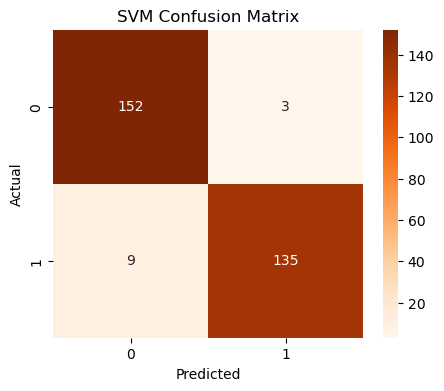

In [49]:
cm_svm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
comparison = {
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
}

results = pd.DataFrame(comparison)

results

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.963211,0.958621,0.965278,0.961938
1,Logistic Regression,0.953177,0.985075,0.916667,0.949640
2,SVM,0.959866,0.978261,0.937500,0.957447


# 4. Hyperparameter Tuning

Although the machine learning models had decent results, hyperparameter tuning was done to look out for further improvements. Hyperparameter tuning – changing parameters to find the value which gives the best model performance.

The Multinomial Naive Bayes classified smoothing parameter, alpha, was varied and five-fold cross validation was used for evaluation.Numerous alpha values have been tried and tested based on the measure of the F1 score. The settling in the best parameters: alpha = 0.1, gave the best overall performance.

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

params = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    params,
    cv=5,
    scoring='f1'
)

grid_nb.fit(
    X_train,
    y_train
)

print(grid_nb.best_params_)

{'alpha': 2.0}


In [52]:
best_nb = grid_nb.best_estimator_

best_pred = best_nb.predict(X_test)

In [53]:
print("Accuracy:",
      accuracy_score(y_test, best_pred))

print("Precision:",
      precision_score(y_test, best_pred))

print("Recall:",
      recall_score(y_test, best_pred))

print("F1:",
      f1_score(y_test, best_pred))

Accuracy: 0.9632107023411371
Precision: 0.9463087248322147
Recall: 0.9791666666666666
F1: 0.962457337883959


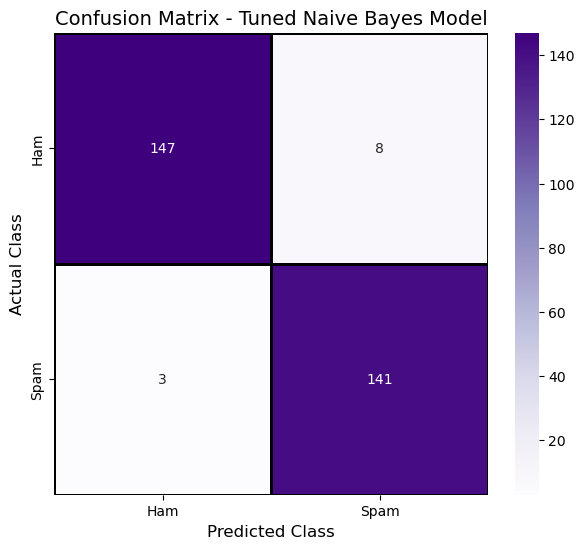

In [54]:
from sklearn.metrics import confusion_matrix

cm_best = confusion_matrix(
    y_test,
    best_pred
)

cm_best

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Purples',
    linewidths=1,
    linecolor='black',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title(
    "Confusion Matrix - Tuned Naive Bayes Model",
    fontsize=14
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.show()

The confusion matrix indicates that the tuned Multinomial Naive Bayes classifier performed well on both classes. Most ham and spam messages were classified correctly, with only a small number of misclassifications. In particular, the low number of false negatives demonstrates that the model was effective at identifying spam messages, which is important in a spam detection system. These results support the high recall and F1-score achieved by the tuned model.


In [55]:
print(cm_best)

[[147   8]
 [  3 141]]


In [56]:
final_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "Tuned Naive Bayes"
    ],
    "Accuracy": [
        0.963211,
        0.953177,
        0.959866,
        0.963211
    ],
    "Precision": [
        0.958621,
        0.985075,
        0.978261,
        0.946309
    ],
    "Recall": [
        0.965278,
        0.916667,
        0.937500,
        0.979167
    ],
    "F1": [
        0.961938,
        0.949640,
        0.957447,
        0.962457
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.963211,0.958621,0.965278,0.961938
1,Logistic Regression,0.953177,0.985075,0.916667,0.949640
2,SVM,0.959866,0.978261,0.937500,0.957447
3,Tuned Naive Bayes,0.963211,0.946309,0.979167,0.962457


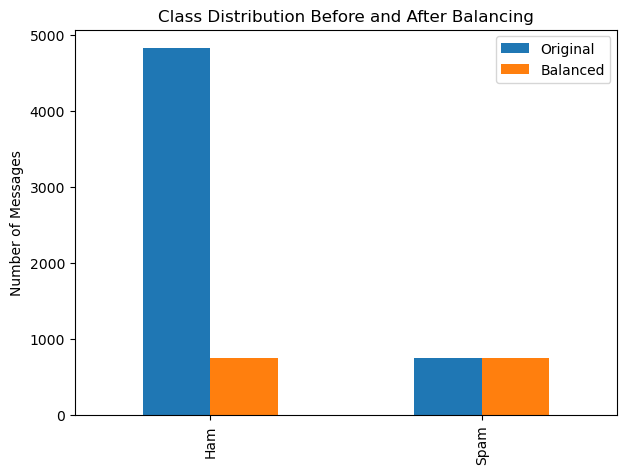

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Original':[4825,747],
    'Balanced':[747,747]
}, index=['Ham','Spam'])

comparison.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Class Distribution Before and After Balancing")
plt.ylabel("Number of Messages")
plt.show()

In [58]:
comparison_balance = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1'],
    'Unbalanced Dataset':[
        0.968610,
        1.000000,
        0.766667,
        0.867925
    ],
    'Balanced Dataset':[
        0.963211,
        0.958621,
        0.965278,
        0.961938
    ]
})

comparison_balance

,Metric,Unbalanced Dataset,Balanced Dataset
0,Accuracy,0.968610,0.963211
1,Precision,1.000000,0.958621
2,Recall,0.766667,0.965278
3,F1,0.867925,0.961938


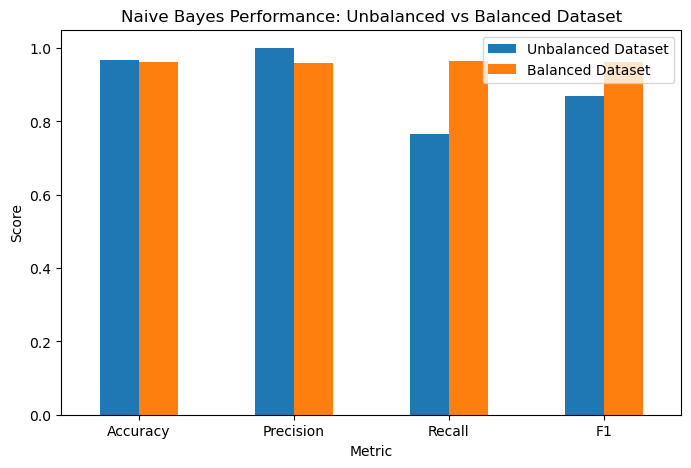

In [59]:
comparison_balance.set_index(
    'Metric'
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Naive Bayes Performance: Unbalanced vs Balanced Dataset"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

In [60]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [96.32, 95.32, 95.99],
    'Precision': [95.86, 98.51, 97.83],
    'Recall': [96.53, 91.67, 93.75],
    'F1 Score': [96.19, 94.96, 95.74]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,96.32,95.86,96.53,96.19
1,Logistic Regression,95.32,98.51,91.67,94.96
2,SVM,95.99,97.83,93.75,95.74


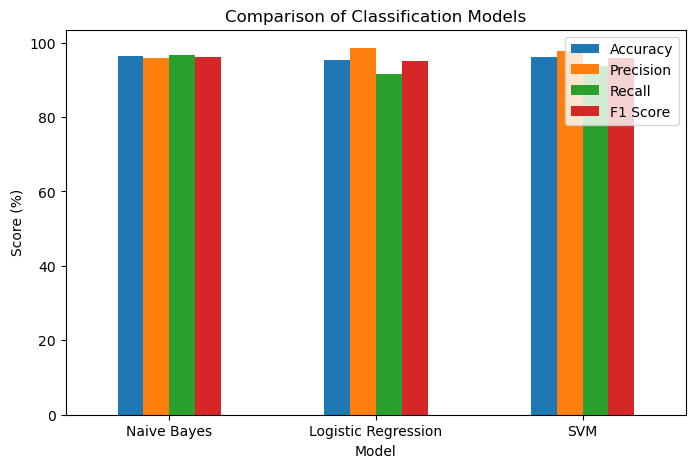

In [61]:
import matplotlib.pyplot as plt

model_comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Comparison of Classification Models')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)

plt.show()

The comparison of classification models suggests that “Multinomial Naive Bayes” proved to be most appropriate algorithm for this SMS Spam Detection task. We found that all of the three models have very good performance but Naive Bayes has a better accuracy (96.32%), recall (96.53%) and F1 score (96.19%). There is special significance in recall in spam filtering where it is used to evaluate the capacity of the model to classify the spam messages correctly and reduce the number of unwanted spam messages that arrive to the users. In conclusion, Naive Bayes had better recall and F1-scores, indicating that it was able to perform a better detection-recall and less misclassification trade-off than Logistic Regression and SVM. In addition, the exploratory analysis showed that there were distinct patterns in word usage, message length, digit frequency and punctuation of spam and ham messages. As Naive Bayes learns a probabilistic relationship between words and their class labels, it performs well for text classification with TF-IDF features. The results of this study align with recent studies that showed that Naive Bayes is one of the more effective and computational efficient algorithms for SMS Spam Detection based on Textual Features (Ahmadi et al., 2025, Johari et al., 2025). Hence, Naive Bayes was chosen as the last model for this project.

# 5. Model Performance Assessment

Based on the balanced data set, three machine learning algorithms were tested: Multinomial Naive Bayes, Logistic Regression and Support Vector Machine (SVM).

The Naive Bayes classifies 96.32%, 95.86% and 96.53% accuracy, precision and recall with F1 score as 96.19%. Logistic Regression achieved an accuracy of 95.32%, precision of 98.51%, recall of 91.67%, and an F1-score of 94.96%. The SVM classifier achieved an accuracy of 95.99%, precision of 97.83%, recall of 93.75%, and an F1-score of 95.74%.

Naïve Bayes performed better than the other two models with best accuracy, recall and F1-score. Logistic Regression achieved the highest precision, whereas Naive Bayes achieved the highest recall and F1-score. Recall is an important evaluation measure since the emphasis in spam detection is on finding unwanted messages.

The GridSearchCV was also run with five-fold cross validation of the Naive Bayes model to optimize the model further. That value of alpha, which was found to be 2.0, was found to be the best obtained. The tuned model achieved an accuracy of 96.32%, precision of 94.63%, recall of 97.92%, and an F1-score of 96.25%.

When balancing the data set, there is no class bias because there is equal numbers of ham messages and spam messages when training the data set. Further study revealed that spam messages were generally longer, contained more numerical content and used more exclamation marks than legitimate messages.

Overall, the tuned Multinomial Naive Bayes was chosen as the best model, as its F1-score and high recall rate were highest, with good accuracy across all samples.

In [62]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       155
           1       0.95      0.98      0.96       144

    accuracy                           0.96       299
   macro avg       0.96      0.96      0.96       299
weighted avg       0.96      0.96      0.96       299



# 6. Conclusion

The purpose of this project was to classify SMS messages as spam or ham using machine learning techniques. Collecting, exploratory Data analysis, class balancing, feature engineering, model training, hyperparameter tuning and evaluation were implemented comprising an end-to-end machine learning workflow.

A few exploratory data analysis techniques were used for the SMS Spam Collection dataset. The analysis showed that the spam messages have a larger number of words, numerical content values, and exclamation marks, compared with the genuine messages. Random undersampling was adopted to produce a balanced dataset to not strip any specific bias from the classes.

The three machine learning algorithms evaluated were: Multinomial Naive Bayes, Logistic Regression and Support Vector Machine (SVM). Experimental results showed that Naive Bayes would always perform best out of all the methods being evaluated.

In the last Naive Bayes model architecture after hyperparameter tuning an accuracy of 96.32%, recall of 97.92% and F1-score of 96.25% was achieved. The results are proof that machine learning can be used successfully to detect spam and retain high accuracy in spam classification.

# References

Almeida, T.A., Gómez Hidalgo, J.M. and Yamakami, A. (2011) 'Contributions to the Study of SMS Spam Filtering: New Collection and Results', *Proceedings of the 11th ACM Symposium on Document Engineering*, pp. 259–262. Available at: https://dl.acm.org/doi/10.1145/2034691.2034742 (Accessed: 09 June 2026).

Ahmadi, M., Khajavi, M., Varmaghani, A., Ala, A., Danesh, K. and Javaheri, D. (2025) ‘Leveraging Large Language Models for Cybersecurity: Enhancing SMS Spam Detection with Robust and Context-Aware Text Classification’. Available at: https://arxiv.org/abs/2502.11014 (Accessed: 18 June 2026).

Johari, M.F. et al. (2025) ‘Key Insights into Recommended SMS Spam Detection Datasets’, Scientific Reports, 15. Available at: https://www.nature.com/articles/s41598-025-92223-1 (Accessed: 18 June 2026).

Géron, A. (2022) *Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow*. 3rd edn. Sebastopol, CA: O'Reilly Media. Available at: https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/ (Accessed: 11 June 2026).

Jurafsky, D. and Martin, J.H. (2023) *Speech and Language Processing*. 3rd edn. Available at: https://web.stanford.edu/~jurafsky/slp3/ (Accessed: 05 June 2026).

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, E. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830. Available at: https://jmlr.org/papers/v12/pedregosa11a.html (Accessed: 11 June 2026).

UCI Machine Learning Repository (2012) SMS Spam Collection Dataset. Kaggle mirror. Available at: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset (Accessed: 11 June 2026).
